# Data import
Just about reading the CSV and looking at basic facts. I'm aware of the risks that come with CSV; I know that floats tend to uh get truncated or rounded. The guess column serves no purpose, neither does the count one and neither the IPs. This was all useful during the data collection, but won't serve any purpose for the rest. 
I'm however surprised to see no nulls in the hops and latency attributes. 

In [1]:
from pathlib import Path 
import pandas as pd 

measurements = pd.read_csv(
    Path("raw_output.csv"), 
    skip_blank_lines=True, 
    header=0)

measurements["latency"] = pd.to_numeric(measurements.latency, errors='coerce')
measurements["hops"] = pd.to_numeric(measurements.hops, errors='coerce')
measurements.info()

<class 'pandas.DataFrame'>
RangeIndex: 11799 entries, 0 to 11798
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            11799 non-null  int64  
 1   origin        11799 non-null  str    
 2   ground_truth  11799 non-null  str    
 3   guess         0 non-null      float64
 4   ip_v4         11799 non-null  str    
 5   ip_v6         2437 non-null   str    
 6   latency       11799 non-null  float64
 7   hops          11799 non-null  float64
 8   count         11799 non-null  int64  
 9   date_time     11799 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 1.5 MB


In [2]:
measurements.drop(columns=["count", "ip_v4", "ip_v6", "guess", "date_time", "id"], inplace=True)

measurements = measurements[measurements.origin != "NordVPN"]

There appear to be many outliers. This means we will have to avoid standardising our dataset, as this might destroy the properties of our features. Indeed, this simply means the measurements' distribution is non gaussian and normalisation is a better alternative. Furthermore, there is a clear left tail on both the latency and the number of hops.  

Text(0.5, 1.0, 'hops')

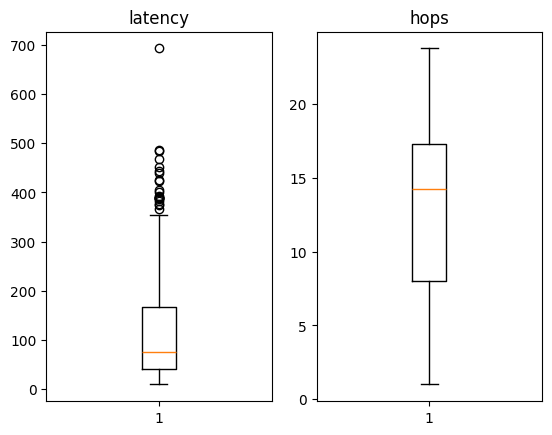

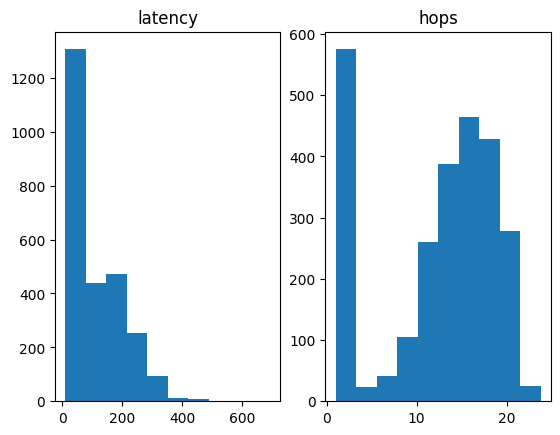

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

axes[0].boxplot(measurements["latency"])
axes[0].set_title("latency")

axes[1].boxplot(measurements["hops"])
axes[1].set_title("hops")

fig, axes = plt.subplots(1, 2)

axes[0].hist(measurements["latency"])
axes[0].set_title("latency")

axes[1].hist(measurements["hops"])
axes[1].set_title("hops")

One can notice above that some country names are in uppercase, whilst some others are in lowercase. Transforming this all in uppercase would be better.  

In [4]:
counts = measurements.groupby(['origin', 'ground_truth']).size().reset_index(name='count')
counts.sort_values('count', ascending=False, inplace=True)
counts.head(30)

,origin,ground_truth,count
154,RIPE,US,289
74,RIPE,DE,235
48,Mullvad,us,203
123,RIPE,NL,123
83,RIPE,FR,97
84,RIPE,GB,79
67,RIPE,CH,61
56,RIPE,AT,57
101,RIPE,IT,57
106,RIPE,KZ,50


In [5]:
from sklearn.compose import ColumnTransformer
import sklearn
from sklearn.preprocessing import FunctionTransformer

measurements['ground_truth'] = measurements['ground_truth'].str.upper()

counts = measurements.groupby(['origin', 'ground_truth']).size().reset_index(name='count')
counts.sort_values('count', ascending=False, inplace=True)

counts.groupby("ground_truth").count()

,origin,count
ground_truth,,
AE,1,1
AF,1,1
AL,2,2
AM,1,1
AO,1,1
...,...,...
US,2,2
UY,1,1
VE,1,1


Fundamentally, the data we have collected comes from two sources:
1) the RIPE network, that allows measurements 
2) two major VPN providers, that freely provide a list of their servers online

The first source would be used as training and dev set, whilst the second as the final test set. 
Because we are dealing with two very different data sources, questions regarding the distribution of classes come into play. Hence the need to take a look at the different distributions of both sources.

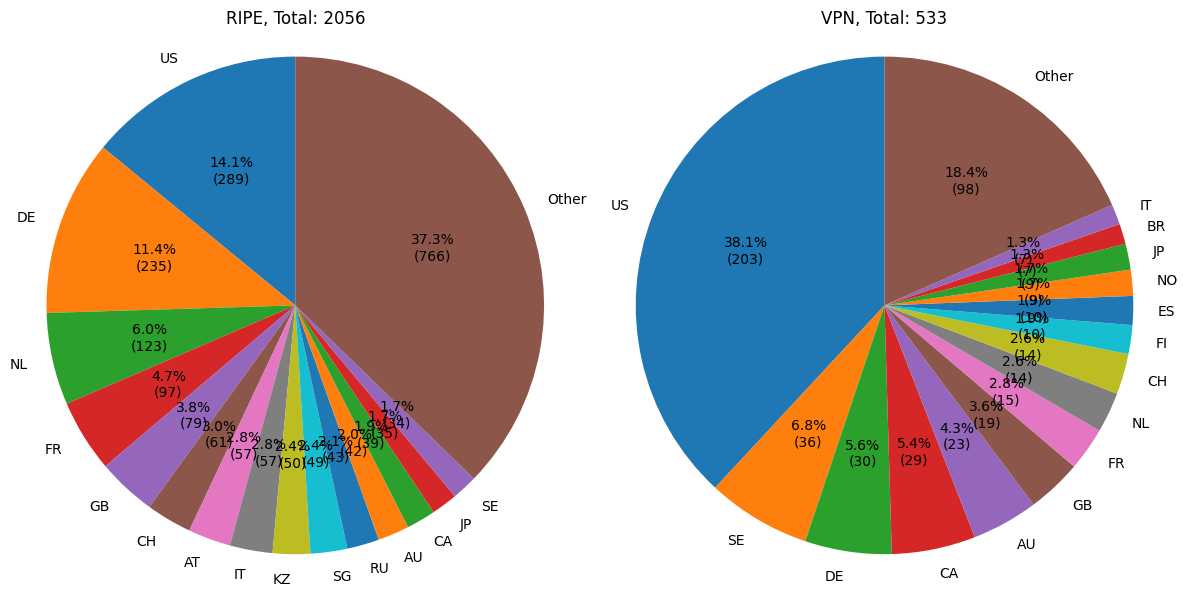

In [ ]:
# Separate each origins 
origins = measurements['origin'].unique()
fig, axes = plt.subplots(1, 2, figsize=(12,6))

def cust_format(x):
    return '{:.1f}%\n({:.0f})'.format(x, origin_counts["count"].sum()*x/100)

for ax, origin in zip(axes, origins):
    origin_counts = counts[counts['origin'] == origin].copy()
    
    top = origin_counts.iloc[:15]
    other_sum = origin_counts.iloc[15:]['count'].sum()
     
    sizes = list(top['count']) + ([other_sum] if other_sum > 0 else [])
    labels = list(top['ground_truth']) + (['Other'] if other_sum > 0 else [])

    ax.pie(sizes, labels=labels, autopct=cust_format, startangle=90)
    
    if origin == "Mullvad":
        origin = "VPN"
    ax.set_title(f"{origin}, Total: {origin_counts["count"].sum()}")
    ax.axis('equal')
    

plt.tight_layout()
plt.show()

The dataset will be split into a training set, a dev set, and a test set, per Geron's own recommendations; thus holdout validation is our chosen validation technique, for now. The training set and dev set will come from our RIPE anchors. The final test set will come from our VPNs. We will go for stratified sampling on as to make sure both splits are representative of our whole dataset. 
A major point one can suppose by looking at the distribution of the RIPE piechart is that class imbalance will be a major issue. Some countries, like the USA, are overrepresented compared to other countries such as Algeria. SMOTE will be used to fix this issue through means of oversampling in the upcoming pipelines.
The NordVPN samples will be dropped alltogether => it doesn't make sense to validate on a dataset larger than our training dataset. 

In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

min_samples = 10

grouped = measurements.groupby(measurements.origin)
traindev_set = grouped.get_group("RIPE")

# Keep only classes with at least min_samples
# otherwise won't be able to stratify 
# see: https://github.com/davidsbatista/text-classification/issues/1
traindev_set = traindev_set[traindev_set.groupby("ground_truth")["ground_truth"].transform("size") >= min_samples]
traindev_set.count()

origin          1798
ground_truth    1798
latency         1798
hops            1798
dtype: int64

Making sure we exclude in the future all countries absent from our training set from our test set.

In [8]:
set_ripe = set(grouped.get_group("RIPE")['ground_truth'].unique())
set_mullvad = set(grouped.get_group("Mullvad")['ground_truth'].unique())

missing = set_mullvad - set_ripe
measurements = measurements[~measurements['ground_truth'].isin(missing)]

In [9]:
# test size -> 0.2 means 20% 
# the stratification is essential as it means the distribution of classes is identical
train_set, dev_set = train_test_split(traindev_set, test_size=0.2, stratify=traindev_set["ground_truth"], random_state=1312)

data, classes = SMOTE(k_neighbors=3, sampling_strategy='minority').fit_resample(train_set[["hops", "latency"]], train_set["ground_truth"]) # type: ignore
train_set = pd.DataFrame(data, columns=["hops", "latency"])
train_set["ground_truth"] = classes

train_set.count()

measurements.to_csv("clean_dataset.csv", index=False)